# 🧩 Day 1 · Solve the Tasks — PyTorch Fundamentals

This notebook is your **practice workbook** for today. Every task works the same way:

1. Read the short explanation and the 💡 **hint**.
2. Write your answer in the **TODO** cell. It runs without errors even before you fill it in (it just prints `TODO`).
3. Then open the **✅ Solution** cell below it and compare.

Try first, peek second. A wrong guess that you then fix teaches you more than a solution you only read.

| Part | Task | Time |
|---|---|---|
| 0 | Setup | 2 min |
| 1 | Tensors | 15 min |
| 2 | Gradient descent & autograd | 20 min |
| 3 | The training loop | 20 min |
| 4 | Is the model any good? | 15 min |
| 5 | 🏁 Final challenge: "Five bugs" | 25 min |

Everything here runs on a normal laptop CPU in under 3 minutes. No GPU and no downloads are needed.

## Part 0: Setup

Run this cell first. `torch.manual_seed(0)` fixes the random numbers, so you get the same results as your neighbour (and as the numbers written in this notebook).

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.9.1+cpu


---
## Task 1 — Tensors (15 min)

A **tensor** is a box of numbers with a **shape**. Think of an egg carton: shape `(2, 6)` means 2 rows of 6 eggs.
Most PyTorch errors are shape errors, so being able to *predict* a shape in your head is a real superpower.

### Exercise 1a — Predict the shape

Without running anything, guess the shape of each result. Write the guess as a tuple, e.g. `(3, 4)`. A single-number shape is written `(5,)`.

| # | Expression | Idea it tests |
|---|---|---|
| 1 | `torch.ones(3, 1) + torch.ones(4)` | **broadcasting** (PyTorch stretches size-1 dimensions to match) |
| 2 | `torch.ones(2, 3) @ torch.ones(3, 5)` | **matrix multiplication** (`@`) |
| 3 | `torch.arange(24).view(2, 3, 4).permute(2, 0, 1)` | `view` (reshape) and `permute` (reorder the dimensions) |
| 4 | `torch.ones(5, 3).sum(dim=0)` | `sum` along one dimension |
| 5 | `torch.ones(5).unsqueeze(1)` | `unsqueeze` (add a new dimension of size 1) |

💡 **Hint:**
* Broadcasting lines the shapes up **from the right**. Two sizes fit if they are equal or one of them is 1.
* `(a, b) @ (b, c)` gives `(a, c)`: the inner sizes must match and they disappear.
* `sum(dim=0)` **removes** dimension 0. Imagine squashing the rows together into one row.
* `permute(2, 0, 1)` means "new order = old dim 2, then old dim 0, then old dim 1".

In [2]:
# TODO: replace each None with your guess, e.g. (3, 4)
my_guesses = {
    1: None,
    2: None,
    3: None,
    4: None,
    5: None,
}

**Checker:** run this cell to compare your guesses with the real shapes.

In [3]:
expressions = {
    1: lambda: torch.ones(3, 1) + torch.ones(4),
    2: lambda: torch.ones(2, 3) @ torch.ones(3, 5),
    3: lambda: torch.arange(24).view(2, 3, 4).permute(2, 0, 1),
    4: lambda: torch.ones(5, 3).sum(dim=0),
    5: lambda: torch.ones(5).unsqueeze(1),
}

def check_shapes(guesses):
    for k, make in expressions.items():
        real = tuple(make().shape)
        guess = guesses.get(k)
        if guess is None:
            print(f"{k}: TODO (no guess yet)")
        else:
            mark = "✅" if tuple(guess) == real else "❌"
            print(f"{k}: your guess {tuple(guess)}  real {real}  {mark}")

check_shapes(my_guesses)

1: TODO (no guess yet)
2: TODO (no guess yet)
3: TODO (no guess yet)
4: TODO (no guess yet)
5: TODO (no guess yet)


#### ✅ Solution (reveal after trying)

In [4]:
answers = {
    1: (3, 4),     # (3,1) and (4,) -> (3,1) and (1,4) -> both stretch -> (3,4)
    2: (2, 5),     # (2,3) @ (3,5): the inner 3s match and disappear
    3: (4, 2, 3),  # view -> (2,3,4); permute(2,0,1) takes dims in order 4, 2, 3
    4: (3,),       # dim 0 (the 5 rows) is squashed away, 3 columns stay
    5: (5, 1),     # a new size-1 dimension is added at position 1
}
check_shapes(answers)

1: your guess (3, 4)  real (3, 4)  ✅
2: your guess (2, 5)  real (2, 5)  ✅
3: your guess (4, 2, 3)  real (4, 2, 3)  ✅
4: your guess (3,)  real (3,)  ✅
5: your guess (5, 1)  real (5, 1)  ✅


### Exercise 1b — Fix the broadcasting bug

We have a table `x` with **100 rows** (students) and **3 columns** (height in cm, weight in kg, monthly screen time in hours).
We want to **centre each column**: subtract the column's average, so every column then has an average of 0. This is a very common first step before training.

A teammate wrote:

```python
x_centred = x - x.mean(dim=1, keepdim=True)
```

It runs without any error. But it is **silently wrong**. "Silently wrong" is the worst kind of bug: no red error message, just wrong numbers.

**Your job:** find out why, and fix it. Check: after the fix, all three column averages should be (almost) 0.

💡 **Hint:** print the shape of `x.mean(dim=1, keepdim=True)`. Does it hold one average per **column** (3 numbers) or one per **row** (100 numbers)?
`dim=0` goes *down* the rows (one result per column). `dim=1` goes *across* a row (one result per row).

In [5]:
g = torch.Generator().manual_seed(0)
x = torch.randn(100, 3, generator=g) * torch.tensor([10.0, 12.0, 30.0]) + torch.tensor([170.0, 65.0, 120.0])

x_centred_buggy = x - x.mean(dim=1, keepdim=True)          # the teammate's version
print("shape of the mean we subtract:", tuple(x.mean(dim=1, keepdim=True).shape))
print("column averages after the BUGGY centring:", x_centred_buggy.mean(dim=0))

# TODO: write the correct version
x_centred = None

if x_centred is None:
    print("TODO: fix the centring")
else:
    print("column averages after YOUR centring:", x_centred.mean(dim=0))

shape of the mean we subtract: (100, 1)
column averages after the BUGGY centring: tensor([ 50.8513, -54.7885,   3.9371])
TODO: fix the centring


#### ✅ Solution (reveal after trying)

In [6]:
x_centred = x - x.mean(dim=0)          # (100,3) - (3,)  -> one average per column, broadcast down all rows
print("shape of the mean we subtract:", tuple(x.mean(dim=0).shape))
print("column averages after the FIX:", x_centred.mean(dim=0))
print("all close to 0?", torch.allclose(x_centred.mean(dim=0), torch.zeros(3), atol=1e-4))

shape of the mean we subtract: (3,)
column averages after the FIX: tensor([-1.3733e-06, -4.4632e-06, -1.0681e-06])
all close to 0? True


**Why was it silently wrong?** `x.mean(dim=1, keepdim=True)` has shape `(100, 1)`: it is the average of **each row**, which mixes centimetres, kilograms and hours together (meaningless!). Because of `keepdim=True`, the shape `(100, 1)` broadcasts perfectly against `(100, 3)`, so PyTorch never complains. The column averages above show the damage: they are far from 0.

Without `keepdim=True`, `x - x.mean(dim=1)` would try `(100, 3) - (100,)` and **crash** (3 does not match 100). A crash is annoying, but at least you notice it. **Lesson:** after any reduction (`mean`, `sum`, ...), print the shape and ask "one number per *what*?"

---
## Task 2 — Gradient descent & autograd (20 min)

The **gradient** (or derivative) tells you the slope: "if I nudge `w` a little bit up, how much does `f` change?"
Imagine standing on a hill in thick fog. You cannot see the valley, but you can feel the slope under your feet. **Gradient descent** = take a small step downhill, feel again, repeat.

**Autograd** is PyTorch's automatic slope calculator. You mark a tensor with `requires_grad=True`, compute something, call `.backward()`, and the slope appears in `.grad`.

### Exercise 2a — Let autograd do your homework

Take `f(w) = w**3 + 2*w` at `w = 2`.
By hand: `f'(w) = 3w² + 2`, so `f'(2) = 3·4 + 2 = 14`.

Use autograd to get the same number.

💡 **Hint:** three lines: create `w = torch.tensor(2.0, requires_grad=True)`, compute `f`, call `f.backward()`. Then read `w.grad`.

In [7]:
# TODO: compute the gradient of f(w) = w**3 + 2*w at w = 2 with autograd
w = torch.tensor(2.0, requires_grad=True)
# f = ...
# f.backward()

if w.grad is None:
    print("TODO: call f.backward() so that w.grad gets filled")
else:
    print("autograd:", w.grad.item(), "| by hand:", 3 * 2**2 + 2)

TODO: call f.backward() so that w.grad gets filled


#### ✅ Solution (reveal after trying)

In [8]:
w = torch.tensor(2.0, requires_grad=True)
f = w**3 + 2 * w
f.backward()
print("f(2)      =", f.item())
print("autograd  =", w.grad.item())
print("by hand   =", 3 * 2**2 + 2)

f(2)      = 12.0
autograd  = 14.0
by hand   = 14


### Exercise 2b — Learning-rate hunt

The **learning rate** (`lr`) is your **step size** when walking downhill.
We minimise `loss = (w - 3)**2`. The best value is clearly `w = 3`. We start at `w = 0`.

One gradient-descent step is: `w = w - lr * gradient`, and here the gradient is `2 * (w - 3)`.

For each `lr` in `[0.01, 0.1, 0.5, 1.0, 1.1]`, count how many steps it takes until `|w - 3| < 0.01` (stop after 200 steps).
If it never gets there, say **why**: is it just *too slow*, does it *oscillate* (bounce back and forth forever) or does it *diverge* (fly away to huge numbers)?

💡 **Hint:** a plain Python loop with a float is enough, no tensors needed. Keep a list of the `w` values so you can look at the last few and see what happened.

In [9]:
def steps_to_reach(lr, w=0.0, max_steps=200):
    # TODO: run gradient descent on (w - 3)**2.
    # Return the number of steps needed to get |w - 3| < 0.01,
    # or a short text such as "too slow", "oscillates" or "diverges".
    return "TODO"

for lr in [0.01, 0.1, 0.5, 1.0, 1.1]:
    print(f"lr = {lr:<5} -> {steps_to_reach(lr)}")

lr = 0.01  -> TODO
lr = 0.1   -> TODO
lr = 0.5   -> TODO
lr = 1.0   -> TODO
lr = 1.1   -> TODO


#### ✅ Solution (reveal after trying)

In [10]:
def steps_to_reach(lr, w=0.0, max_steps=200):
    history = []
    for step in range(1, max_steps + 1):
        grad = 2 * (w - 3)
        w = w - lr * grad
        history.append(w)
        if abs(w - 3) < 0.01:
            return f"{step} step" + ("" if step == 1 else "s")
    if abs(w - 3) > 1000:
        return f"diverges (w = {w:.2e} after {max_steps} steps)"
    if abs(w - 3) >= 3 - 1e-9:                 # still as far away as at the start
        return f"oscillates (last values: {history[-2]:.1f}, {history[-1]:.1f})"
    return f"too slow (w = {w:.3f} after {max_steps} steps)"

print(f"{'lr':<6}| result")
print("-" * 50)
for lr in [0.01, 0.1, 0.5, 1.0, 1.1]:
    print(f"{lr:<6}| {steps_to_reach(lr)}")

lr    | result
--------------------------------------------------
0.01  | too slow (w = 2.947 after 200 steps)
0.1   | 26 steps
0.5   | 1 step
1.0   | oscillates (last values: 6.0, 0.0)
1.1   | diverges (w = -2.06e+16 after 200 steps)


**What we measured:**

| lr | what happens |
|---|---|
| 0.01 | **too slow**: after 200 steps `w` is only at about 2.947 (not yet within 0.01 of 3) |
| 0.1 | reaches the goal in **26 steps** |
| 0.5 | reaches the goal in **1 step**: here `w - 0.5·2·(w-3) = 3` exactly. A lucky perfect step size for this simple bowl. |
| 1.0 | **oscillates**: `w` jumps 0 → 6 → 0 → 6 ... forever. Every step overshoots by exactly the same amount. |
| 1.1 | **diverges**: every step overshoots by *more*, and after 200 steps `w` is about −2·10¹⁶ |

**Why?** Each step multiplies the distance to 3 by `(1 - 2·lr)`. For 0.01 that is 0.98 (tiny progress), for 0.5 it is 0 (done), for 1.0 it is −1 (same distance, other side), for 1.1 it is −1.2 (bigger distance every time).
**Lesson:** too small = slow, too big = bouncing or exploding. Real models have no formula for the "perfect" lr, so we try a few values.

### Exercise 2c — Fit a line by hand

Fake data: `y = 2x + 1` plus a little noise. Learn `w` and `b` with a **manual** training loop (no `nn`, no `optim`). Check: `w ≈ 2` and `b ≈ 1`.

The four magic ingredients:
* `requires_grad=True`: "please track the slope for this tensor".
* `loss.backward()`: compute all slopes.
* `with torch.no_grad():` "this is just an update, don't record it as part of the model's maths".
* `w.grad.zero_()`: wipe the old slope. PyTorch **adds** new gradients to old ones, so without this they pile up.

💡 **Hint:** the loss is the mean squared error, `((y_pred - y) ** 2).mean()`. The update is `w -= lr * w.grad`.

In [11]:
g = torch.Generator().manual_seed(0)
x_line = torch.linspace(-1, 1, 100)
y_line = 2 * x_line + 1 + 0.1 * torch.randn(100, generator=g)

w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(200):
    y_pred = None        # TODO: the model's prediction, using w, b and x_line
    loss = None          # TODO: mean squared error between y_pred and y_line
    if loss is None:
        print("TODO: fill in y_pred and loss (then backward, update, zero the grads)")
        break
    # TODO: loss.backward()
    # TODO: with torch.no_grad(): update w and b
    # TODO: zero the gradients of w and b

print(f"w = {w.item():.3f}, b = {b.item():.3f}")

TODO: fill in y_pred and loss (then backward, update, zero the grads)
w = 0.000, b = 0.000


#### ✅ Solution (reveal after trying)

In [12]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(200):
    y_pred = w * x_line + b
    loss = ((y_pred - y_line) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()

print(f"w = {w.item():.3f} (target 2), b = {b.item():.3f} (target 1), final loss = {loss.item():.4f}")

w = 2.000 (target 2), b = 1.004 (target 1), final loss = 0.0105

---
## Task 3 — The training loop (20 min)

Every PyTorch training loop, from a tiny line fit to a huge language model, repeats the same **five lines**.
Remember them like a recipe: **clear, guess, score, blame, fix.**

### Exercise 3a — Put the five lines in order

The five lines below are scrambled. Put them in the order they run inside **one** training step.

💡 **Hint:** you need a prediction before you can score it, a score (loss) before you can compute slopes, and slopes before you can update. And the old slopes must be cleared before new ones are computed.

In [13]:
scrambled = [
    "loss.backward()",
    "optimizer.step()",
    "loss = loss_fn(pred, y)",
    "optimizer.zero_grad()",
    "pred = model(x)",
]

# TODO: copy the strings from `scrambled` into the right order
my_order = []

**Checker:**

In [14]:
def check_order(order):
    if not order:
        print("TODO: fill in my_order")
        return
    if sorted(order) != sorted(scrambled):
        print("❌ use each of the five lines exactly once")
        return
    pos = {line: i for i, line in enumerate(order)}
    rules = [
        ("pred = model(x)", "loss = loss_fn(pred, y)", "predict before you can score"),
        ("loss = loss_fn(pred, y)", "loss.backward()", "you need a loss before backward"),
        ("loss.backward()", "optimizer.step()", "you need gradients before you step"),
    ]
    ok = True
    for first, second, why in rules:
        if pos[first] > pos[second]:
            print(f"❌ '{first}' must come before '{second}': {why}")
            ok = False
    if pos["loss.backward()"] < pos["optimizer.zero_grad()"] < pos["optimizer.step()"]:
        print("❌ zero_grad() between backward() and step() wipes the gradients before they are used")
        ok = False
    if ok:
        print("✅ correct order:")
        for i, line in enumerate(order, 1):
            print(f"   {i}. {line}")

check_order(my_order)

TODO: fill in my_order


#### ✅ Solution (reveal after trying)

In [15]:
my_order = [
    "optimizer.zero_grad()",     # 1. clear  : wipe old gradients
    "pred = model(x)",           # 2. guess  : forward pass
    "loss = loss_fn(pred, y)",   # 3. score  : how wrong are we?
    "loss.backward()",           # 4. blame  : which weight caused how much error?
    "optimizer.step()",          # 5. fix    : nudge every weight downhill
]
check_order(my_order)

✅ correct order:
   1. optimizer.zero_grad()
   2. pred = model(x)
   3. loss = loss_fn(pred, y)
   4. loss.backward()
   5. optimizer.step()


Small detail: `zero_grad()` only has to happen somewhere **before** `backward()`. Some people put it at the very end of the step instead. The checker accepts both.

### Exercise 3b — What if we forget `zero_grad()`?

PyTorch **adds** each new gradient to the one already stored in `.grad`. That is useful in some advanced tricks, but in a normal loop it is a bug.
Analogy: a shopping receipt. If the cashier never clears the screen, each new customer pays for everything all earlier customers bought too.

**Data:** `make_moons` from scikit-learn: two interleaving half-circles of points (two classes) in 2-D. A straight line cannot separate them, so we need a small neural network.

**Your job:** the helper `train_moons(use_zero_grad)` is ready. It trains the **same** small network (same seed, same data) and returns the loss of every step plus the test accuracy.
Call it twice (`True` and `False`), plot both loss curves in one chart and print both accuracies.

💡 **Hint:** `plt.plot(losses, label="...")` twice, then `plt.legend()`.

In [16]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)
X_tr, X_te = torch.tensor(X_tr, dtype=torch.float32), torch.tensor(X_te, dtype=torch.float32)
y_tr, y_te = torch.tensor(y_tr, dtype=torch.int64), torch.tensor(y_te, dtype=torch.int64)
print("train:", tuple(X_tr.shape), "| test:", tuple(X_te.shape))


def train_moons(use_zero_grad, steps=300, lr=0.01):
    torch.manual_seed(0)                                   # identical starting weights every time
    model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 16), nn.ReLU(), nn.Linear(16, 2))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    for step in range(steps):                              # full batch: all 700 training points each step
        if use_zero_grad:
            optimizer.zero_grad()
        loss = loss_fn(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (model(X_te).argmax(dim=1) == y_te).float().mean().item()
    return losses, acc

train: (700, 2) | test: (300, 2)


In [17]:
# TODO: call train_moons(True) and train_moons(False), plot both loss curves, print both accuracies
print("TODO: compare training with and without zero_grad")

TODO: compare training with and without zero_grad


#### ✅ Solution (reveal after trying)

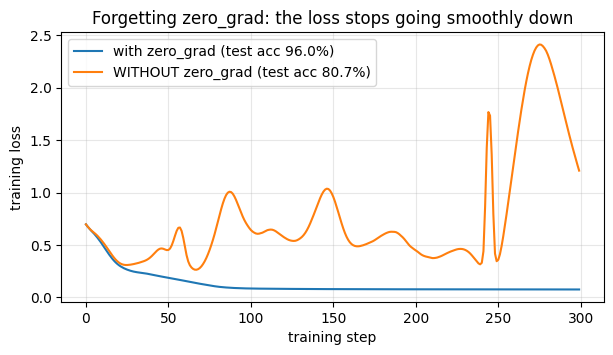

with zero_grad    : final loss 0.076 | test accuracy 96.0%
WITHOUT zero_grad : final loss 1.209 | test accuracy 80.7%


In [18]:
losses_ok, acc_ok = train_moons(use_zero_grad=True)
losses_bad, acc_bad = train_moons(use_zero_grad=False)

plt.figure(figsize=(7, 3.5))
plt.plot(losses_ok, label=f"with zero_grad (test acc {acc_ok:.1%})")
plt.plot(losses_bad, label=f"WITHOUT zero_grad (test acc {acc_bad:.1%})")
plt.xlabel("training step"); plt.ylabel("training loss")
plt.title("Forgetting zero_grad: the loss stops going smoothly down")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"with zero_grad    : final loss {losses_ok[-1]:.3f} | test accuracy {acc_ok:.1%}")
print(f"WITHOUT zero_grad : final loss {losses_bad[-1]:.3f} | test accuracy {acc_bad:.1%}")

**What we measured:** with `zero_grad()` the loss goes smoothly down to about 0.076 and the test accuracy is **96.0%**. Without it, the loss jumps up and down wildly, ends at 1.209 (higher than where it started!), and the test accuracy is only **80.7%**.

**Why?** Without clearing, step 300 uses the *sum* of all 300 gradients so far. Old gradients point to where the weights *used to be*, so the model keeps getting pushed by stale, outdated directions and overshoots again and again.

Honest note: the damage is not always this big. With plain SGD and a small learning rate, piled-up gradients act a bit like *momentum* and training can even look fine for a while. That is exactly what makes this bug sneaky: it does not crash, it just makes training unreliable. Always write `zero_grad()`.

---
## Task 4 — Is the model any good? (15 min)

### Exercise 4a — Early stopping by hand

**Early stopping** = stop training when the **validation loss** (the loss on data the model does not train on) stops improving. Like baking a cake: take it out when it is done, before it starts to burn. Training further would only make the model memorise the training data (**overfitting**).

**Patience** = how many epochs in a row *without a new best* you are willing to wait before you stop. (An **epoch** is one full pass over the training data.)

Here are the validation losses of 12 epochs (epoch 1 is the first value):

```
val_losses = [0.92, 0.71, 0.58, 0.50, 0.46, 0.44, 0.45, 0.43, 0.46, 0.49, 0.53, 0.58]
```

Find:
1. `best_epoch`: the epoch with the lowest validation loss,
2. `stop_epoch`: the epoch at which early stopping with **patience = 2** stops training.

💡 **Hint:** walk through the list keeping `best_so_far` and a counter `bad_epochs`. A new best resets the counter to 0; otherwise add 1. Stop as soon as the counter reaches the patience. Watch out for epoch 7: it is worse than epoch 6, but epoch 8 is a new best!

In [19]:
val_losses = [0.92, 0.71, 0.58, 0.50, 0.46, 0.44, 0.45, 0.43, 0.46, 0.49, 0.53, 0.58]

# TODO: compute these two numbers (epochs are counted from 1)
best_epoch = None
stop_epoch = None

**Checker:**

In [20]:
def check_early_stopping(best, stop):
    if best is None or stop is None:
        print("TODO: fill in best_epoch and stop_epoch")
        return
    print("best_epoch:", best, "✅" if best == 8 else "❌")
    print("stop_epoch:", stop, "✅" if stop == 10 else "❌")

check_early_stopping(best_epoch, stop_epoch)

TODO: fill in best_epoch and stop_epoch


#### ✅ Solution (reveal after trying)

In [21]:
def early_stop(losses, patience):
    best_so_far, best_epoch, bad_epochs = float("inf"), None, 0
    for epoch, loss in enumerate(losses, start=1):
        if loss < best_so_far:
            best_so_far, best_epoch, bad_epochs = loss, epoch, 0
        else:
            bad_epochs += 1
        if bad_epochs == patience:
            return best_epoch, epoch
    return best_epoch, len(losses)

best_epoch, stop_epoch = early_stop(val_losses, patience=2)
check_early_stopping(best_epoch, stop_epoch)
print("with patience = 1 we would stop at epoch", early_stop(val_losses, patience=1)[1],
      "and keep epoch", early_stop(val_losses, patience=1)[0], "as best")

best_epoch: 8 ✅
stop_epoch: 10 ✅
with patience = 1 we would stop at epoch 7 and keep epoch 6 as best


**Result:** the best epoch is **8** (loss 0.43). With patience 2, epochs 9 and 10 are both worse, so training stops at **epoch 10** and we keep the weights from epoch 8.
With patience 1 we would have stopped too early, at epoch 7, and missed the better epoch 8. Small bumps in the validation loss are normal, so a little patience pays off.

### Exercise 4b — One number can hide a weak class

In Notebook 02 we trained a CNN on FashionMNIST (10 kinds of clothing) and got **91.22%** test accuracy. Sounds great! But is it great for **every** kind of clothing?

Below is the **real confusion matrix** of that CNN on the 10,000 test images (from `Day1_PyTorch_Fundamentals/02_train_cnn_fashionmnist.ipynb`, model `models/fashion_cnn.pth`).
**Row** = the true class, **column** = what the model predicted. The diagonal holds the correct predictions.

**Recall** of a class = "of all the *real* shirts, how many did the model *find*?"

`recall = correct predictions for that class / number of real items of that class = diagonal value / row sum`

**Your job:** compute the recall of each class, find the **worst** class and compare it with the overall accuracy.

💡 **Hint:** `cm.diagonal()` gives the diagonal, `cm.sum(dim=1)` gives the row sums. Overall accuracy = `cm.diagonal().sum() / cm.sum()`. `argmin()` finds the position of the smallest value.

In [22]:
CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

cm = torch.tensor([
    # predicted:  T-sh  Trou  Pull  Dres  Coat  Sand  Shir  Snea   Bag  Boot
    [843,    0,   21,   24,    3,    1,   99,    0,    9,    0],   # true T-shirt/top
    [  0,  976,    0,   18,    1,    0,    4,    0,    1,    0],   # true Trouser
    [  9,    0,  879,   10,   57,    0,   44,    0,    1,    0],   # true Pullover
    [ 10,    1,    7,  948,   11,    0,   22,    0,    1,    0],   # true Dress
    [  1,    0,   57,   38,  862,    0,   41,    0,    1,    0],   # true Coat
    [  0,    0,    0,    0,    0,  985,    0,   11,    0,    4],   # true Sandal
    [ 94,    1,   70,   41,   80,    0,  703,    0,   11,    0],   # true Shirt
    [  0,    0,    0,    0,    0,    8,    0,  968,    0,   24],   # true Sneaker
    [  0,    1,    1,    4,    1,    1,    0,    3,  989,    0],   # true Bag
    [  0,    0,    0,    0,    0,    4,    1,   26,    0,  969],   # true Ankle boot
])
print("test images:", cm.sum().item())

# TODO: compute recall per class, the worst class, and the overall accuracy
recall = None

if recall is None:
    print("TODO: compute recall = diagonal / row sums")

test images: 10000
TODO: compute recall = diagonal / row sums


#### ✅ Solution (reveal after trying)

In [23]:
recall = cm.diagonal() / cm.sum(dim=1)
overall_acc = (cm.diagonal().sum() / cm.sum()).item()

for name, r in sorted(zip(CLASSES, recall.tolist()), key=lambda t: t[1]):
    bar = "█" * int(r * 40)
    print(f"{name:12s} {r:.3f} {bar}")

worst = recall.argmin().item()
print(f"\noverall accuracy : {overall_acc:.4f}")
print(f"worst class      : {CLASSES[worst]} with recall {recall[worst]:.3f}")
print(f"Shirts mistaken for T-shirt/top: {cm[6, 0].item()}, Coat: {cm[6, 4].item()}, Pullover: {cm[6, 2].item()}")

Shirt        0.703 ████████████████████████████
T-shirt/top  0.843 █████████████████████████████████
Coat         0.862 ██████████████████████████████████
Pullover     0.879 ███████████████████████████████████
Dress        0.948 █████████████████████████████████████
Sneaker      0.968 ██████████████████████████████████████
Ankle boot   0.969 ██████████████████████████████████████
Trouser      0.976 ███████████████████████████████████████
Sandal       0.985 ███████████████████████████████████████
Bag          0.989 ███████████████████████████████████████

overall accuracy : 0.9122
worst class      : Shirt with recall 0.703
Shirts mistaken for T-shirt/top: 94, Coat: 80, Pullover: 70


**Result:** the overall accuracy is **91.22%**, but **Shirt** has a recall of only **0.703**: about 3 out of 10 real shirts are labelled as something else, mostly T-shirt/top (94), Coat (80) and Pullover (70). Meanwhile Bag (0.989) and Sandal (0.985) are almost perfect.

**Lesson:** one overall number is an *average*, and averages hide weak spots. If your shop sells mainly shirts, this "91% model" is right on shirts only 70% of the time. Always look at the per-class numbers (recall, the confusion matrix) before you say "the model is good".

---
## Task 5 — 🏁 Final challenge: "Five bugs" (25 min)

Below is a complete training script for the `make_moons` data from Task 3. It looks reasonable. It contains **exactly 5 bugs**, and each one is a mistake we talked about today.

**Your job:** copy the script into the TODO cell, find and fix all five bugs.
🎯 **Target:** the fixed version reaches **≥ 93% test accuracy**.

**Bug checklist** (one hint per bug):

| # | Where to look | Hint |
|---|---|---|
| 1 | inside the training loop | Something that should happen at the start of *every* step is missing. Remember the five lines from Task 3a. |
| 2 | the line that computes `loss` | `nn.CrossEntropyLoss` wants the **raw scores** (logits). It already does its own softmax inside. |
| 3 | how `y_train` / `y_test` are created | Class labels are *whole numbers* (class 0, class 1). Which `dtype` does `CrossEntropyLoss` want? |
| 4 | the evaluation part | The model contains `Dropout`. Which mode should it be in when we test it? And do we need gradients there? |
| 5 | the optimizer | Remember the learning-rate hunt in Task 2b. Is this step size sensible? |

💡 **Hint:** fix them one at a time and re-run after each fix. The first run will crash. That is bug 3 shouting at you. The other four bugs are *silent*: no error, just a worse model.

In [24]:
def buggy_script():
    # ----- data -----
    X, y = make_moons(n_samples=1000, noise=0.2, random_state=0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    # ----- model -----
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(2, 32), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(32, 2),
    )
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0)

    # ----- training -----
    for epoch in range(300):
        model.train()
        probs = torch.softmax(model(X_train), dim=1)
        loss = loss_fn(probs, y_train)
        loss.backward()
        optimizer.step()

    # ----- evaluation -----
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean().item()
    print(f"final train loss {loss.item():.3f} | test accuracy {acc:.1%}")


try:
    buggy_script()
except Exception as e:
    print("💥 the buggy script crashed:", type(e).__name__, "-", e)

💥 the buggy script crashed: RuntimeError - expected scalar type Long but found Float


In [25]:
# TODO: paste the script here as fixed_script(), fix the 5 bugs, and run it.
def fixed_script():
    print("TODO: paste and fix the script")

fixed_script()

TODO: paste and fix the script


#### ✅ Solution (reveal after trying)

In [26]:
def fixed_script(verbose=True):
    # ----- data -----
    X, y = make_moons(n_samples=1000, noise=0.2, random_state=0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.int64)          # FIX 3: class labels must be int64
    y_test = torch.tensor(y_test, dtype=torch.int64)

    # ----- model -----
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(2, 32), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(32, 2),
    )
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   # FIX 5: sensible learning rate

    # ----- training -----
    for epoch in range(300):
        model.train()
        optimizer.zero_grad()                                   # FIX 1: clear old gradients
        logits = model(X_train)                                 # FIX 2: raw logits, no softmax
        loss = loss_fn(logits, y_train)
        loss.backward()
        optimizer.step()

    # ----- evaluation -----
    model.eval()                                                # FIX 4a: dropout OFF
    with torch.no_grad():                                       # FIX 4b: no gradients needed
        preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean().item()
    if verbose:
        print(f"final train loss {loss.item():.3f} | test accuracy {acc:.1%}")
    return acc

acc_fixed = fixed_script()
print("target reached (>= 93%)?", "✅" if acc_fixed >= 0.93 else "❌")

final train loss 0.146 | test accuracy 95.0%
target reached (>= 93%)? ✅


#### 🔍 Evidence: what each bug does on its own

The cell below runs the script with **only one bug switched on** at a time, so you can see each symptom separately. (You do not need to understand this helper in detail; read the table under it.)

In [27]:
def run_with_bugs(no_zero_grad=False, softmax_first=False, float_labels=False,
                  no_eval=False, huge_lr=False):
    X, y = make_moons(n_samples=1000, noise=0.2, random_state=0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    X_train, X_test = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32)
    label_dtype = torch.float32 if float_labels else torch.int64
    y_train, y_test = torch.tensor(y_train, dtype=label_dtype), torch.tensor(y_test, dtype=label_dtype)
    torch.manual_seed(0)
    model = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Dropout(0.5),
                          nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.5), nn.Linear(32, 2))
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0 if huge_lr else 0.01)
    try:
        for epoch in range(300):
            model.train()
            if not no_zero_grad:
                optimizer.zero_grad()
            out = model(X_train)
            if softmax_first:
                out = torch.softmax(out, dim=1)
            loss = loss_fn(out, y_train)
            loss.backward()
            optimizer.step()
    except Exception as e:
        return f"💥 crash: {type(e).__name__}: {e}"
    if no_eval:
        preds = model(X_test).argmax(dim=1)
    else:
        model.eval()
        with torch.no_grad():
            preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean().item()
    return f"test accuracy {acc:.1%} | final train loss {loss.item():.3f}"

experiments = {
    "all 5 bugs fixed": {},
    "only bug 1 (no zero_grad)": {"no_zero_grad": True},
    "only bug 2 (softmax before loss)": {"softmax_first": True},
    "only bug 3 (float labels)": {"float_labels": True},
    "only bug 4 (no eval / no_grad)": {"no_eval": True},
    "only bug 5 (lr = 1.0)": {"huge_lr": True},
    "bugs 1, 2, 4, 5 (only bug 3 fixed)": {"no_zero_grad": True, "softmax_first": True,
                                           "no_eval": True, "huge_lr": True},
}
for name, bugs in experiments.items():
    print(f"{name:36s} -> {run_with_bugs(**bugs)}")

all 5 bugs fixed                     -> test accuracy 95.0% | final train loss 0.146


only bug 1 (no zero_grad)            -> test accuracy 77.0% | final train loss 0.529


only bug 2 (softmax before loss)     -> test accuracy 95.3% | final train loss 0.361
only bug 3 (float labels)            -> 💥 crash: RuntimeError: expected scalar type Long but found Float


only bug 4 (no eval / no_grad)       -> test accuracy 91.0% | final train loss 0.146


only bug 5 (lr = 1.0)                -> test accuracy 79.7% | final train loss 0.540


bugs 1, 2, 4, 5 (only bug 3 fixed)   -> test accuracy 44.7% | final train loss 0.835


**What we measured:**

| Version | What happens |
|---|---|
| Original buggy script (all 5 bugs) | 💥 **crashes** on the first step: `RuntimeError: expected scalar type Long but found Float` |
| Only bug 3 fixed (bugs 1, 2, 4, 5 still in) | runs, but test accuracy is only **44.7%**: worse than tossing a coin |
| All 5 bugs fixed | test accuracy **95.0%** (final train loss 0.146) ✅ |

Each bug on its own (all others fixed):

| Bug | Symptom we measured | Why |
|---|---|---|
| 1. no `zero_grad()` | accuracy drops to **77.0%** | gradients pile up, the model is pushed by stale directions (Task 3b) |
| 2. softmax before the loss | accuracy is still **95.3%**, but the train loss is stuck at **0.361** and can never go below about 0.31 | the loss applies softmax *again*. Squashing already-squashed numbers means the model can never be "fully sure", so learning signals get weak. On harder data this costs accuracy. A loss that refuses to drop is your clue. |
| 3. `float32` labels | 💥 **crash**: `expected scalar type Long but found Float` | `CrossEntropyLoss` wants class indices as `int64` ("Long"). (Float targets are only allowed when they are full probability tables of shape `(N, 2)`.) |
| 4. no `model.eval()` / `no_grad()` | accuracy drops to **91.0%** | dropout keeps switching off half the neurons *during the test*, so predictions are noisy and change on every run. `no_grad()` does not change accuracy, but saves memory and time. |
| 5. `lr = 1.0` | accuracy drops to **79.7%** | steps are far too big, the weights jump around the valley instead of settling in it (Task 2b) |

Notice: only one of the five bugs gives a red error message. The other four just quietly make the model worse. That is why we always check the numbers against a sensible target.

---
## 🎓 What you proved today

* **Shapes:** you can predict tensor shapes in your head, and you know that broadcasting can make a wrong answer run *without an error* (`dim=0` vs `dim=1`).
* **Gradients:** autograd gives the same slope as your hand calculation, and the learning rate decides between slow, perfect, bouncing and exploding.
* **The loop:** clear → guess → score → blame → fix (`zero_grad`, forward, loss, `backward`, `step`), and you saw what happens when `zero_grad` is missing.
* **Judging a model:** early stopping picks the best epoch on validation data, and per-class recall reveals the weak class (Shirt, 0.703) hiding behind 91% accuracy.
* **Debugging:** you fixed five classic bugs and took a script from a crash to **95% test accuracy**. Most bugs are silent, so always compare against a target.